# Assignment 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns 
import warnings 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2025-04-14 16:30:08.614761: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Q1: 

Use Lab 10 dataset, and split the dataset to 70-30 for training and test respectively.

In [2]:
# We'll ignore any warnings to keep our output clean.
warnings.filterwarnings('ignore')  # This will suppress any warning messages

# Let's start by loading our dataset into a pandas DataFrame.
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'  # URL for the dataset
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']  # Defining column names
raw_dataset = pd.read_csv(url, names=column_names, na_values='?', comment='\t', sep=' ', skipinitialspace=True)  # Loading the dataset into a DataFrame

# Displaying the first few rows of the dataset to get an idea of what it looks like.
print(raw_dataset.head())  # Displaying the first few rows of the DataFrame

df = raw_dataset.copy()  

    MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   Model Year  Origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  


In [3]:
print(df.isnull().sum())
df = df.dropna()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64


In [4]:
print(df.dtypes)

MPG             float64
Cylinders         int64
Displacement    float64
Horsepower      float64
Weight          float64
Acceleration    float64
Model Year        int64
Origin            int64
dtype: object


In [5]:
X = df.drop('Horsepower', axis=1)
y = df['Horsepower']

#70/30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Q2: 

Apply the multiple linear regression method on the dataset to predict “Horsepower” variable using all other features. Report the performance of the model with all regression metrics on both training and test datasets

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [8]:
print("Training Set:")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred)}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred)}")
print(f"R2: {r2_score(y_train, y_train_pred)}")

print("-"*25)

print("Test Set:")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred)}")
print(f"R2: {r2_score(y_test, y_test_pred)}")

Training Set:
MAE: 8.734802964141316
MSE: 152.9393752800965
R2: 0.8944465295485003
-------------------------
Test Set:
MAE: 9.06615604270934
MSE: 141.1299132415703
R2: 0.9085642487028079


In [9]:
LR_y_train_pred = y_train_pred
LR_y_test_pred = y_test_pred

## Q3:
Apply a Deep Artificial Neural Networks on the dataset to predict “Horsepower” variable using all other features. Report the performance of the model with all regression metrics on both training and test datasets. The hyper-parameters’ values and the architecture of the ANN are optional with minimum two hidden layers

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=100, verbose=0)


In [12]:
y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

4/4 [==============================] - 0s 2ms/step


In [13]:
print("Training Set:")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred)}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred)}")
print(f"R2: {r2_score(y_train, y_train_pred)}")

print("-"*25)

print("Test Set:")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred)}")
print(f"R2: {r2_score(y_test, y_test_pred)}")

Training Set:
MAE: 8.560536920589252
MSE: 133.65330458649242
R2: 0.9077571089160087
-------------------------
Test Set:
MAE: 9.590924085196802
MSE: 156.7359874247476
R2: 0.8984533297277779


In [14]:
S_y_train_pred = y_train_pred
S_y_test_pred = y_test_pred

## Q4:

Plot the loss values of training and validation data for the Section (3)

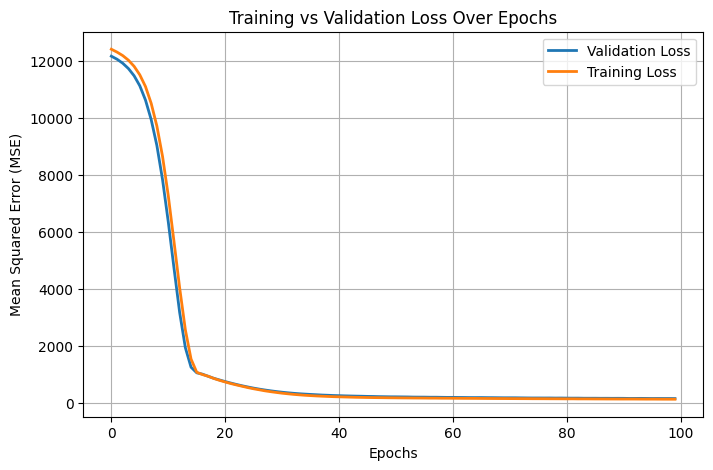

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.title("Training vs Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()
plt.grid(True)
plt.show()

## Q5:
Compare the two model results with all aformentioned metrics and write down your interpretation of the results.